In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "dragonkue/BGE-m3-ko",
    device="cpu"
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [4]:
response = client.embeddings.create(model="text-embedding-3-small", input="안녕하세요 임베딩 테스트입니다.")
len(response.data[0].embedding)

1536

### 군집
- 질문-문서가 아닌 문서끼리 비교하는 작업

In [11]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

In [7]:
data = pd.read_csv("../data/11-1_뉴스정제.csv")
df = data.groupby("카테고리").head(150).reset_index(drop=True)
df.head()

,제목,본문,카테고리,요약,출처URL,정제본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제,"6 6일 현대백화점그룹이 광주시에 문화복합몰을 만든다고 6일 밝혔으며, 광주시는 서...",https://n.news.naver.com/mnews/article/001/001...,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...,경제,이이스항공은 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 출소한 것...,https://n.news.naver.com/mnews/article/003/001...,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...,경제,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 소셜미디어 인스타...,https://n.news.naver.com/mnews/article/366/000...,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...
3,오늘부터 유류세 인하 폭 확대…하반기 바뀌는 세제·금융 정책은,img tag s 지난 30일 서울의 한 주유소. 〈사진 연합뉴스〉 img tag ...,경제,정부는 고유가 상황에 따라 국민의 유류비 부담 완화를 위해 이날부터 유류세를 법정 ...,https://n.news.naver.com/mnews/article/437/000...,img tag s 지난 30일 서울의 한 주유소 사진 연합뉴스 img tag e 오...
4,푸르덴셜생명 더 큰 드림 변액연금보험Ⅱ에 신규펀드 13종 추가,파이낸셜뉴스 푸르덴셜생명보험은 급변하는 금융시장에 대응하기 위해 무배당 더 큰 드림...,경제,지난르덴셜생명보험은 급변하는 금융시장에 대응하기 위해 무배당 더 큰 드림 변액연금보...,https://n.news.naver.com/mnews/article/014/000...,파이낸셜뉴스 푸르덴셜생명보험은 급변하는 금융시장에 대응하기 위해 무배당 더 큰 드림...


In [23]:
df.columns

Index(['제목', '본문', '카테고리', '요약', '출처URL', '정제본문'], dtype='str')

In [10]:
doc_vecs = model.encode(df['정제본문'].tolist(), 
                        normalize_embeddings=True, 
                        show_progress_bar=True,
                        batch_size=4)

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

### k- means 클러스터링
- 지정한 개수만큼 그룹으로 묶는 방식
- 거리기반


In [25]:
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(doc_vecs)
df['군집'] = km.labels_
df['군집'].value_counts()

군집
0    209
1     91
Name: count, dtype: int64

In [28]:
df['카테고리'].unique()

<ArrowStringArray>
['경제', 'IT과학']
Length: 2, dtype: str

In [29]:
df['카테고리'].value_counts()
doc_vecs.shape


(300, 1024)

In [27]:
pd.crosstab(df['군집'], df['카테고리'])

카테고리,IT과학,경제
군집,,
0,135,74
1,15,76


C:\Users\Lee\AppData\Local\Temp\ipykernel_34532\2270266835.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


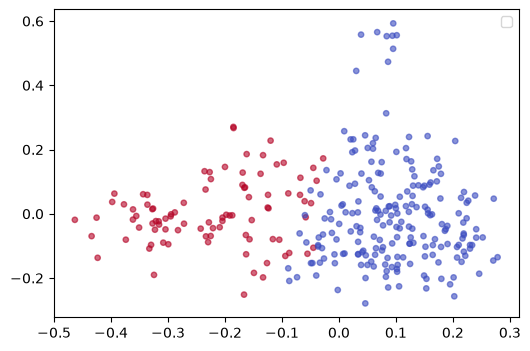

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

coords = PCA(n_components=2).fit_transform(doc_vecs)    # 벡터를 2차원으로 줄인다

plt.figure(figsize=(6, 4))
plt.scatter(coords[:, 0], coords[:, 1], c=df['군집'], cmap="coolwarm", s=15, alpha=0.6)
plt.legend()
plt.show()